# Import Required Libraries

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.layers import Dense, Input, SimpleRNN, Embedding, LSTM
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.datasets import imdb

from sklearn.model_selection import train_test_split

# Load Dataset

In [32]:
(x_train, y_train), (x_test, y_test) = imdb.load_data()

In [33]:
X_train = pad_sequences(x_train, padding='post')
X_test = pad_sequences(x_test, padding='post')

# Building a RNN Model

In [34]:
vocab_size = max([max(sequence) for sequence in X_train])
print(vocab_size)

88586


In [35]:
model = Sequential([
    Embedding(vocab_size, 64),
    # SimpleRNN(32),
    LSTM(32),
    Dense(1, activation="sigmoid")
])

In [36]:
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

In [37]:
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 28s 83ms/step - accuracy: 0.5066 - loss: 0.6933 - val_accuracy: 0.4938 - val_loss: 0.6932
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 26s 82ms/step - accuracy: 0.4887 - loss: 0.6933 - val_accuracy: 0.4938 - val_loss: 0.6932
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 26s 82ms/step - accuracy: 0.5014 - loss: 0.6932 - val_accuracy: 0.4938 - val_loss: 0.6933
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 26s 82ms/step - accuracy: 0.4962 - loss: 0.6933 - val_accuracy: 0.4938 - val_loss: 0.6934
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 26s 82ms/step - accuracy: 0.5010 - loss: 0.6932 - val_accuracy: 0.5062 - val_loss: 0.6931


In [38]:
test_loss, test_acc = model.evaluate(X_test, y_test)

print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

782/782 ━━━━━━━━━━━━━━━━━━━━ 23s 30ms/step - accuracy: 0.5073 - loss: 0.6931
Test Accuracy: 0.5
Test Loss: 0.6931717991828918


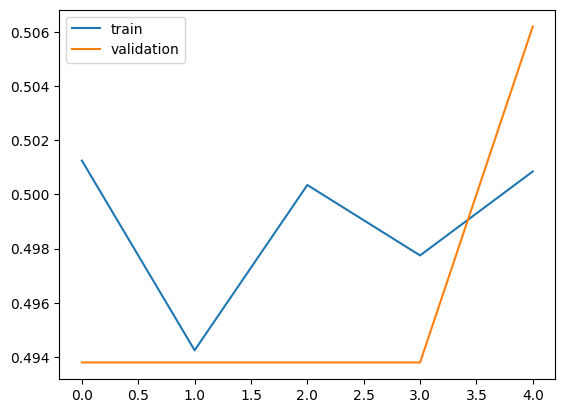

In [39]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['train','validation'])
plt.show()

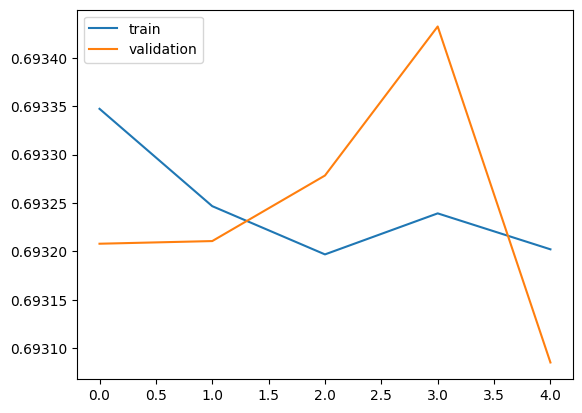

In [40]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['train','validation'])
plt.show()